## Question 1 : Simple Forecast Using Moving Average
### Predict the next value using the last 12-month average.

In [2]:
import pandas as pd
data=pd.read_csv("airline-passengers.csv",
                    parse_dates=["Month"],
                    index_col="Month")

In [3]:
data

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [4]:
last_12=data["Passengers"].tail(12)
prediction=last_12.mean()

In [5]:
print("Predicted next value:",prediction)

Predicted next value: 476.1666666666667


## Question 2 : Autocorrelation and Partial Autocorrelation
### Plot ACF and PACF to determine seasonality

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

<Figure size 1200x500 with 0 Axes>

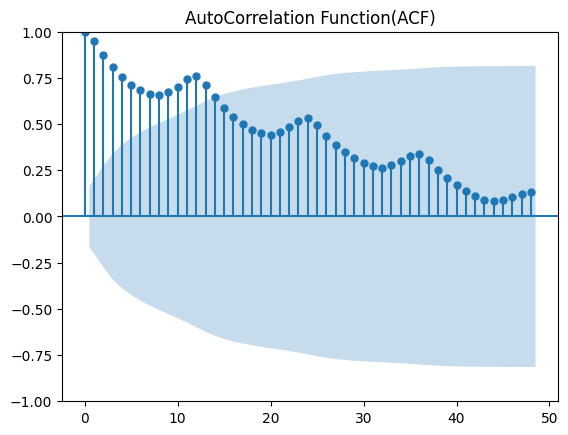

In [7]:
#ACF Plot
plt.figure(figsize=(12,5))
plot_acf(data["Passengers"],lags=48)
plt.title("AutoCorrelation Function(ACF)")
plt.show()

In [8]:
# The ACF plot shows significant autocorrelation at lags 1, 2, 11, and 12. 
# The significant spike at lag 12 indicates a yearly seasonal pattern in the AirPassengers data.

<Figure size 1200x500 with 0 Axes>

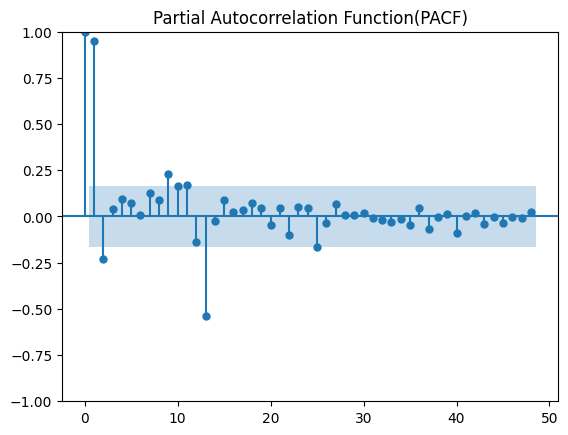

In [9]:
#PACF plot
plt.figure(figsize=(12,5))
plot_pacf(data["Passengers"],lags=48)
plt.title("Partial Autocorrelation Function(PACF)")
plt.show()


In [10]:
# The PACF plot shows significant partial autocorrelation at lags 1 and 2, indicating short-term autoregressive relationships. 
# Lag 12 also shows a significant spike, indicating a relationship at the 12-month seasonal lag.
# Lag 11 is within the confidence band and is therefore not statistically significant.

## Question 3 : Fit ARIMA Model and Forecast
### Fit an ARIMA model to the series and forecast the next 12 months


In [11]:
import pandas as pd
data=pd.read_csv("airline-passengers.csv",
                    parse_dates=["Month"],
                    index_col="Month")

In [12]:
data

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [13]:
#preprocessing
from sklearn.preprocessing import MinMaxScaler
Ms=MinMaxScaler()
data1=Ms.fit_transform(data[["Passengers"]])
print("Len:",data1.shape)

Len: (144, 1)


In [14]:
import warnings
warnings.filterwarnings("ignore")

In [15]:
#Model Creation
orders=[(1,1,1),(1,1,2),(2,3,1),(2,2,2)]
for i in orders:
    from statsmodels.tsa.arima.model import ARIMA
    model=ARIMA(data1,order=i)
    model_fit=model.fit()
    # make prediction
    y_pred=model_fit.predict(0,len(data1)-1)
    from stockFunctions import rmsemape
    rmsemape(data1,y_pred)

RMSE-Testset: 0.05969805796748991
maPe-Testset: 727867773732.135
RMSE-Testset: 0.05739305923272206
maPe-Testset: 733044018511.0437
RMSE-Testset: 0.07289574553934051
maPe-Testset: 114346776079.61168
RMSE-Testset: 0.059758640536665804
maPe-Testset: 660051312474.6218


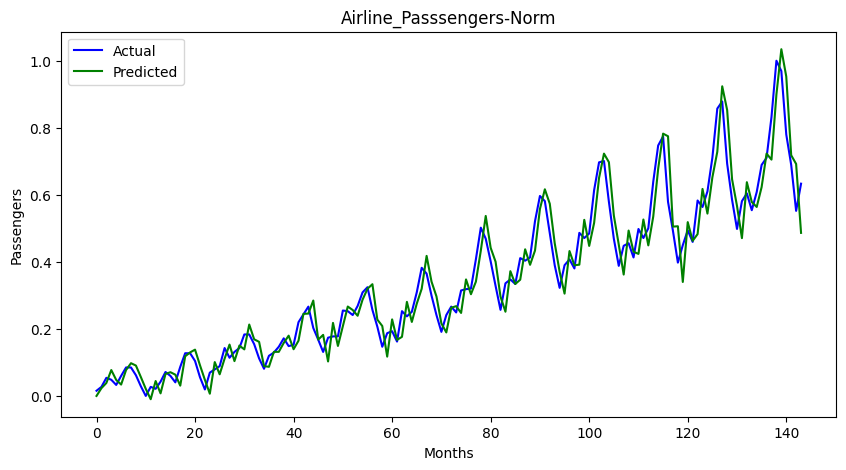

In [16]:
from stockFunctions import graph
graph(data1,y_pred,"Actual","Predicted","Airline_Passsengers-Norm","Months","Passengers")

In [17]:
len(data1)

144

In [20]:
from stockFunctions import conversionOriginal
actual_passengers_test_oriA=conversionOriginal(data1,["Passengers"],Ms)

In [21]:
predicted_passengers_test_oriP=conversionOriginal(y_pred,["Passengers"],Ms)

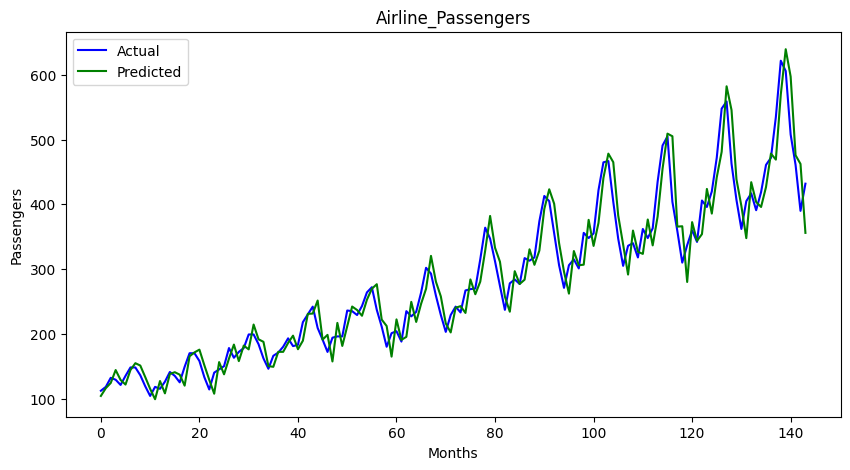

In [22]:
from stockFunctions import graph
graph(actual_passengers_test_oriA,predicted_passengers_test_oriP, "Actual","Predicted","Airline_Passengers","Months","Passengers")

In [23]:
forecast=model_fit.predict(len(data1),len(data1)+11)

In [24]:
forecast

array([0.71788656, 0.69357668, 0.72049564, 0.71187471, 0.72530495,
       0.72465225, 0.73292456, 0.73552914, 0.741731  , 0.74564935,
       0.7510172 , 0.75546495])

In [25]:
from stockFunctions import conversionOriginal
forecast_passenger_test_oriF = conversionOriginal(forecast,["Passengers"],Ms)

In [26]:
forecast_passenger_test_oriF

,Passengers
0,475.865236
1,463.272718
2,477.21674
3,472.7511
4,479.707963
5,479.369868
6,483.654922
7,485.004094
8,488.216659
9,490.246366


In [27]:
forecast_passenger_test_oriF.to_csv("passengers_ARIMA.csv",index=False)

## Question 4 : Load and Visualize the Dataset
### Load the dataset and plot the time series.


In [1]:
import pandas as pd
data=pd.read_csv("daily-min-temperatures.csv",
                 index_col="Date")

In [2]:
data

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5


Text(0, 0.5, 'Temperature')

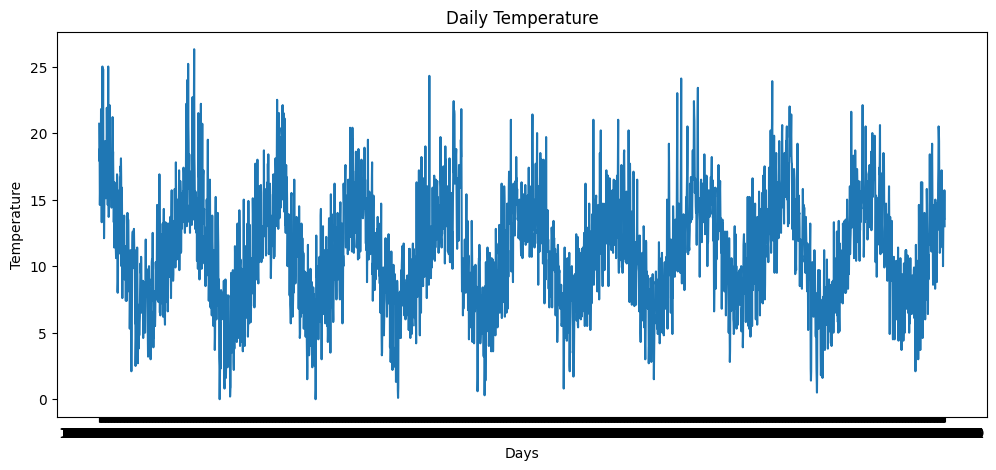

In [4]:
# visualizing the time series
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(data.index,data["Temp"])
plt.title("Daily Temperature")
plt.xlabel("Days")
plt.ylabel("Temperature")

## Question 5 : Check for Seasonality with Monthly Mean
### Calculate the average temperature for each month.

In [6]:
data.index =pd.to_datetime(data.index)

In [7]:
monthly_mean=data.groupby(data.index.month)['Temp'].mean()

In [8]:
print(monthly_mean)

Date
1     15.030323
2     15.373759
3     14.565484
4     12.088333
5      9.866452
6      7.278333
7      6.692581
8      7.891290
9      8.976333
10    10.309355
11    12.479667
12    13.851948
Name: Temp, dtype: float64


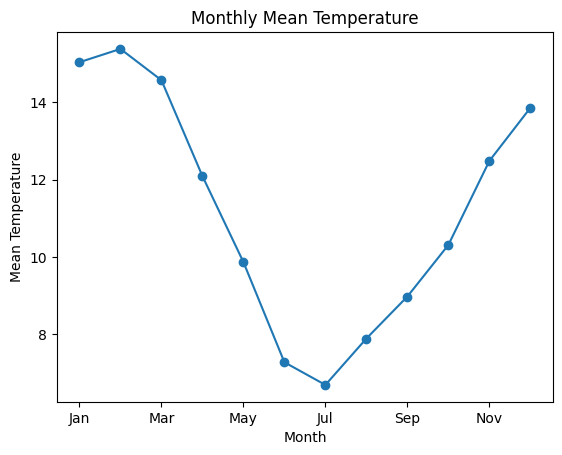

In [11]:
import matplotlib.pyplot as plt

monthly_mean.index = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

monthly_mean.plot(kind='line', marker='o')

plt.xlabel('Month')
plt.ylabel('Mean Temperature')
plt.title('Monthly Mean Temperature')
plt.show()

In [12]:
# The monthly mean temperature shows a seasonal pattern, with temperatures decreasing from January to July and then increasing from August to December. 
# This indicates the presence of seasonality in the temperature data.